In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.resource_utils import split_datasets_path
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation.scoring import *

c:\Users\Lyler\mambaforge\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)

data = data.values


In [6]:
from sklearn.mixture import GaussianMixture
#fit gaussian mixture model
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
gmm.fit(data)

GaussianMixture(n_components=2, random_state=0)

In [11]:
#sample 10k from gmm
samples, _ = gmm.sample(10000)

In [12]:
samples

array([[ 2.26967153e+02,  8.16683074e+01,  5.80190641e+02, ...,
         2.78628681e-01,  2.72981880e-01,  4.45352488e-01],
       [ 5.13019526e+02,  3.75421971e+01,  5.56976276e+02, ...,
        -1.66991281e-01,  8.40590831e-01,  3.26757929e-01],
       [ 4.17967555e+02,  6.41255697e+01,  5.67593643e+02, ...,
         2.54559262e-01, -1.80525937e-01,  9.23126417e-01],
       ...,
       [ 4.72155664e+02,  2.24503357e+01,  6.35393816e+02, ...,
        -4.47346085e-02,  1.34206421e+00, -2.97206133e-01],
       [ 3.99999858e+02,  6.00008342e+01,  5.53550969e+02, ...,
        -1.09049814e-04,  9.99467512e-01,  8.62849677e-04],
       [ 3.99997684e+02,  5.99992101e+01,  5.53552939e+02, ...,
         1.88916330e-04,  9.99733874e-01, -4.56385257e-04]],
      shape=(10000, 99))

In [13]:
print(samples.shape)

(10000, 99)


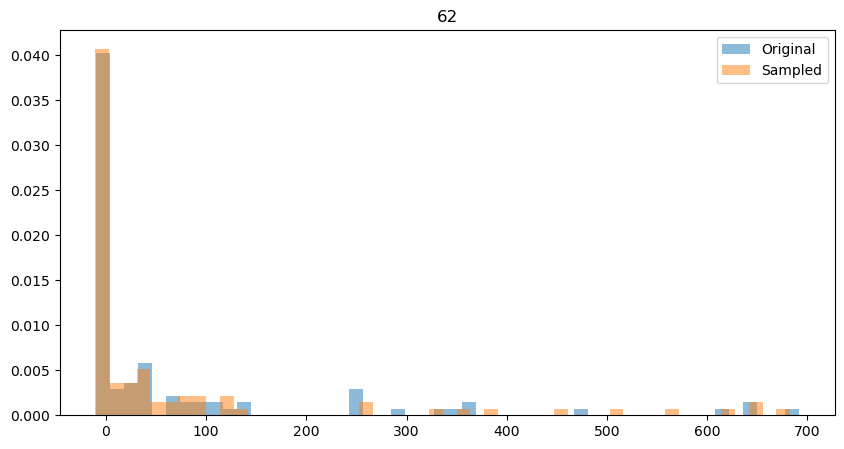

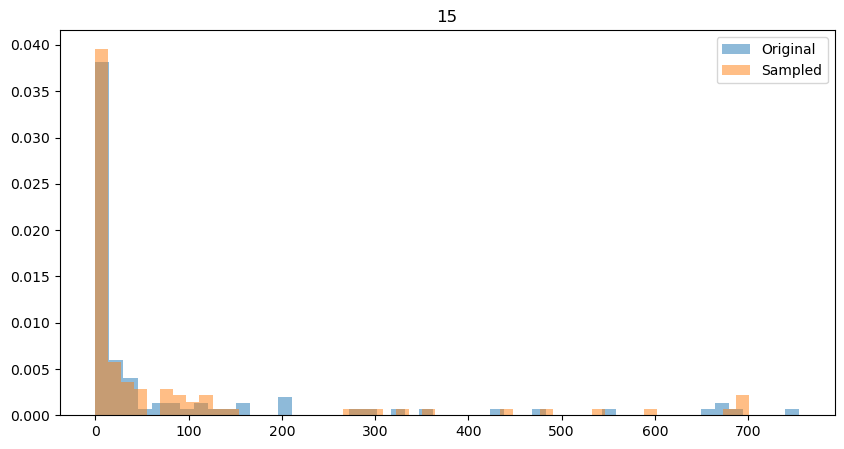

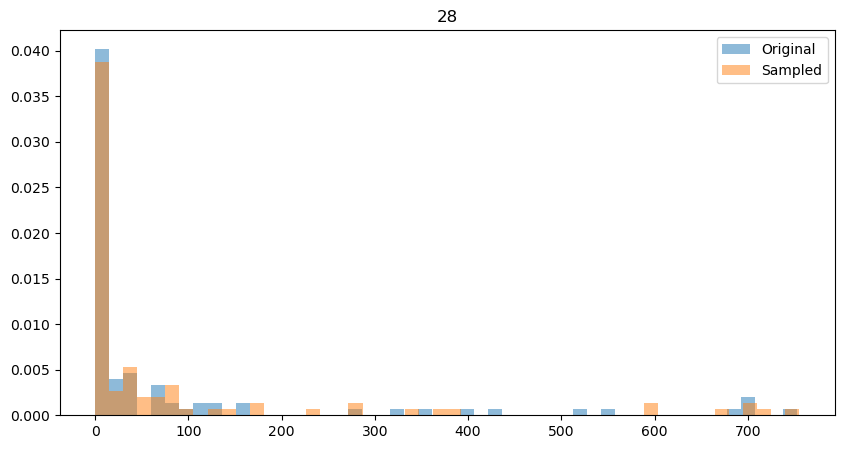

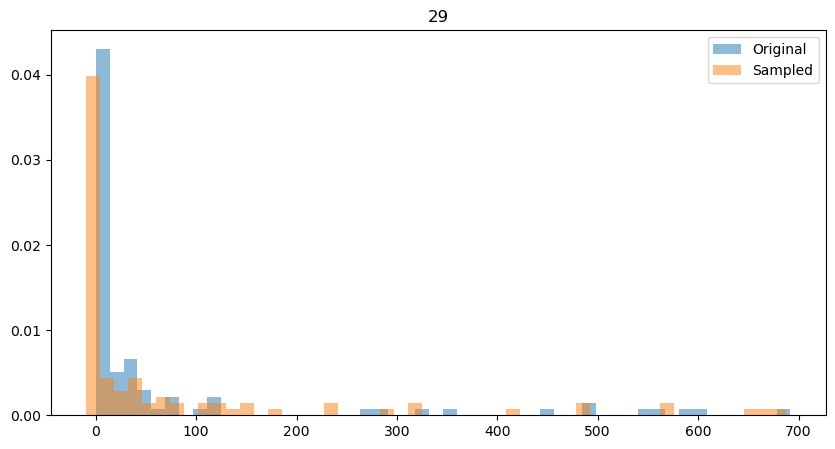

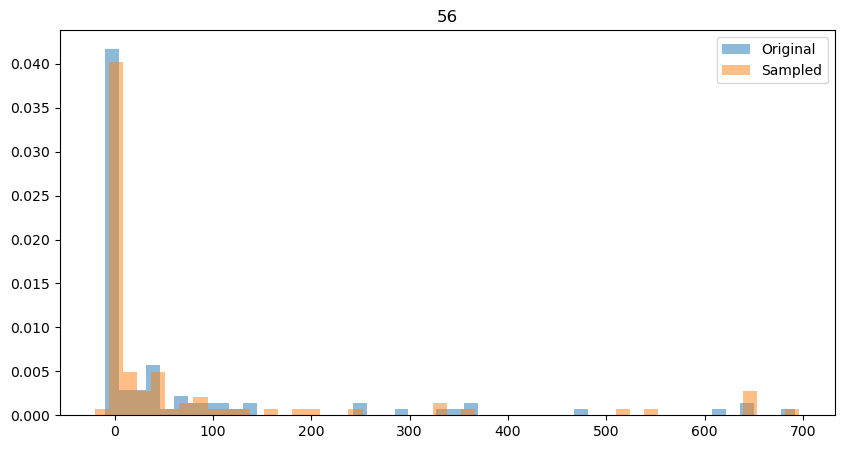

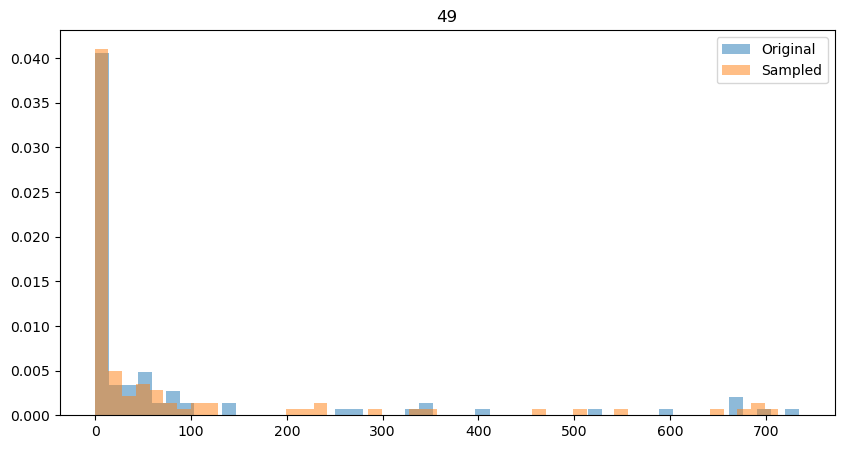

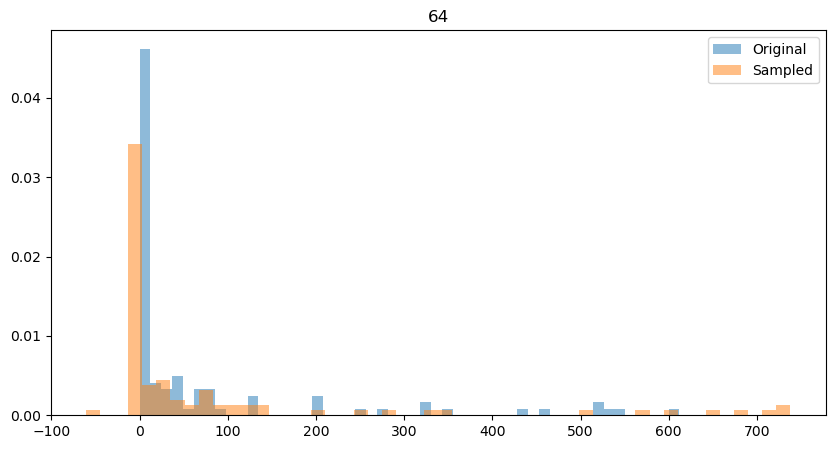

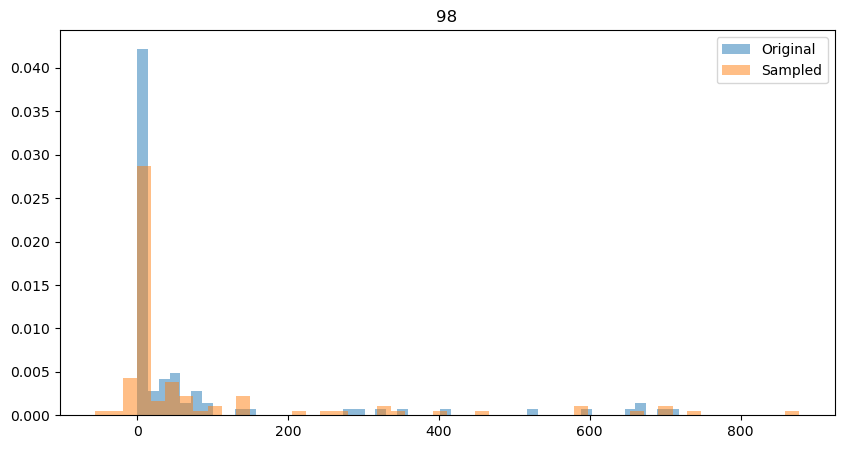

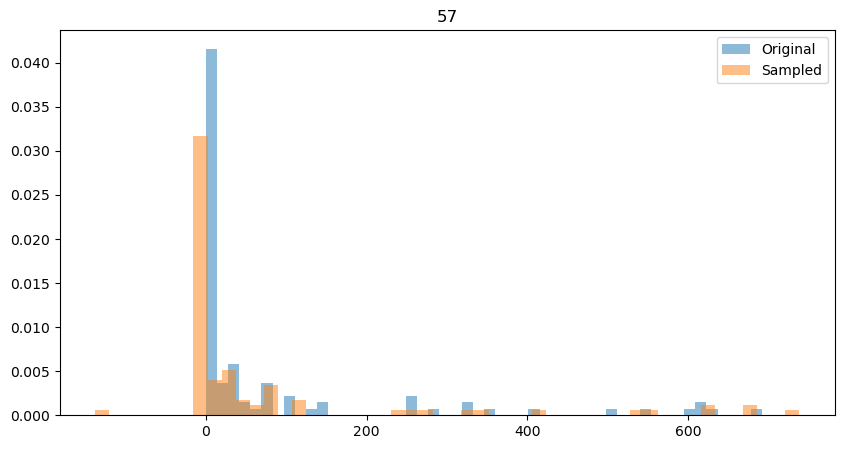

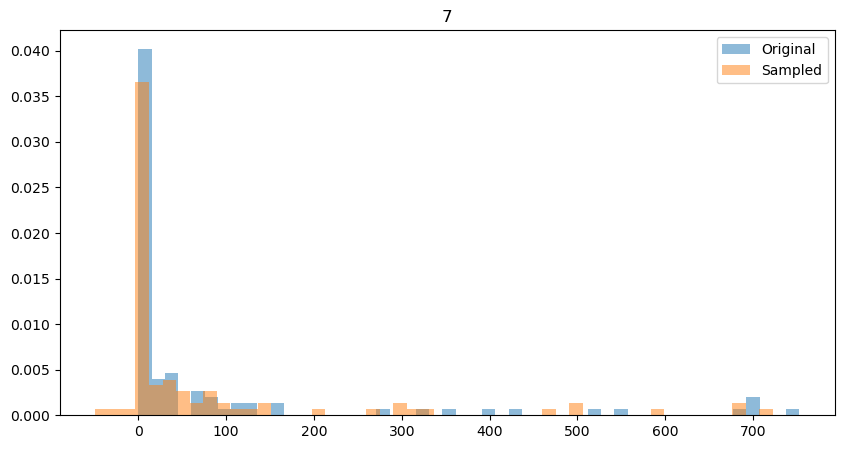

In [17]:
import matplotlib.pyplot as plt
#pick 10 random columns and compare histograms of each one
cols = np.random.choice(data.shape[1], 10, replace=False)
for col in cols:
    plt.figure(figsize=(10, 5))
    plt.hist(data[col], bins=50, alpha=0.5, label="Original", density=True)
    plt.hist(samples[col], bins=50, alpha=0.5, label="Sampled", density=True)
    plt.title(col)
    plt.legend()
    plt.show()